## MODELO DE PREDICION PARA EL CONSUMO DE CONBUSTIBLE

Autor: Jean Marcos Bellido Molina

## Comprension del negocio

Objetivo del negocio:

El consumo eficiente de combustible es un factor importante para fabricantes, concesionarios y consumidores. Poder estimar el rendimiento de combustible de un automóvil ayuda a comparar vehículos, evaluar su eficiencia energética y apoyar la toma de decisiones de compra.

Problema:

Desarrollar un modelo que sea capaz de predecir el rendimiento de combustible utilizando las características técnicas de un automóvil.

Determinar objetivos de minería de datos

Construir un modelo de Regresión Lineal capaz de predecir el valor de MPG utilizando las variables técnicas del vehículo.

Produce Project Plan (Plan del proyecto)

- Recolectar datos.
- Explorar el dataset.
- Limpiar datos.
- Preparar variables.
- Entrenar el modelo.
- Evaluar resultados.
- Presentar conclusiones.

## Comprension de datos

Recolecion de datos

In [1]:
# Importar la librería pandas
import pandas as pd

# Definimos los nombres de las columnas
columnas = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
    "car_name"
]

# Cargar el dataset original
df_auto = pd.read_csv(
    "auto-mpg.data",
    sep=r"\s+",
    header=None,
    names=columnas,
    na_values="?"
)

# Crear una copia del dataset para trabajar
df = df_auto.copy()

Descripcion de datos

In [2]:
# Mostrar las primeras filas del conjunto de datos
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [3]:
# Dimensiones del dataset
df.shape

(398, 9)

In [4]:
# Mostrar información del dataset:
# tipo de datos, valores no nulos y memoria utilizada
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    str    
dtypes: float64(5), int64(3), str(1)
memory usage: 34.4 KB


In [5]:
# Mostrar estadísticas descriptivas de las variables numéricas
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


Exploracion de datos

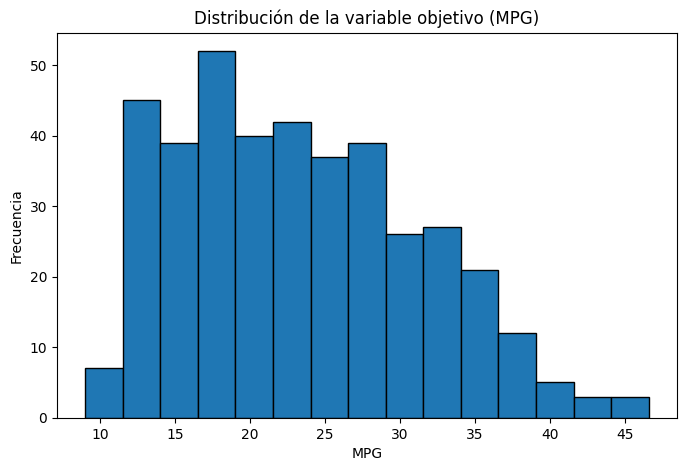

In [6]:
# Importar la librería para generar gráficos
import matplotlib.pyplot as plt

# Mostrar la distribución de la variable objetivo (MPG)
plt.figure(figsize=(8,5))

plt.hist(df["mpg"], bins=15, edgecolor="black")

plt.title("Distribución de la variable objetivo (MPG)")
plt.xlabel("MPG")
plt.ylabel("Frecuencia")

plt.show()

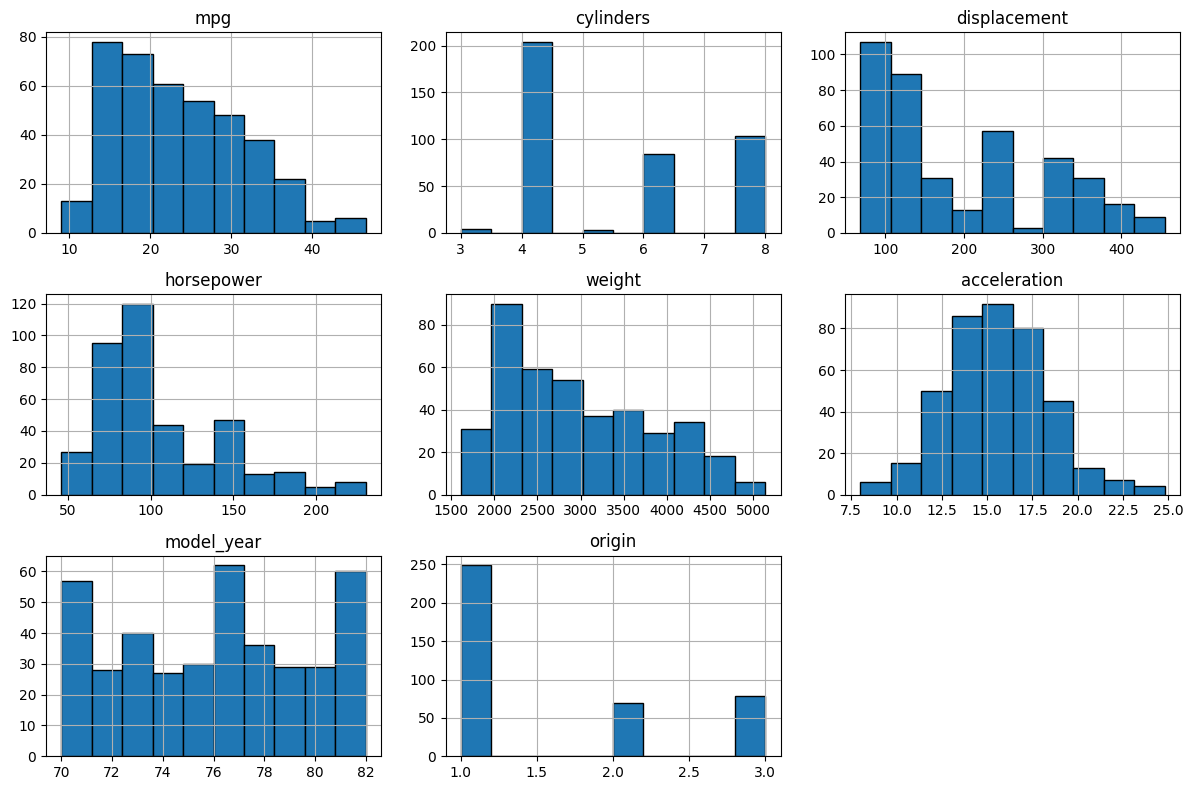

In [7]:
# Mostrar la distribución de todas las variables numéricas
df.hist(figsize=(12,8), edgecolor="black")

plt.tight_layout()
plt.show()

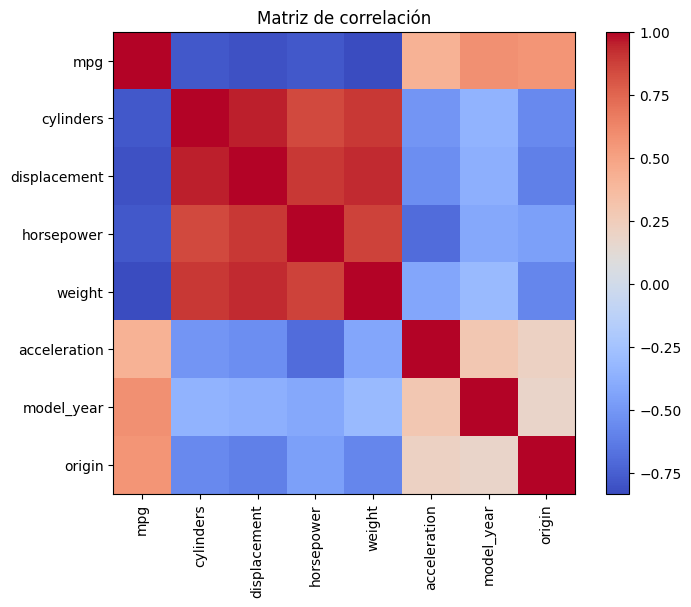

In [8]:
# Calcular la correlación entre las variables numéricas
corr = df.corr(numeric_only=True)

# Mostrar la matriz de correlación
plt.figure(figsize=(8,6))

plt.imshow(corr, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Matriz de correlación")

plt.show()

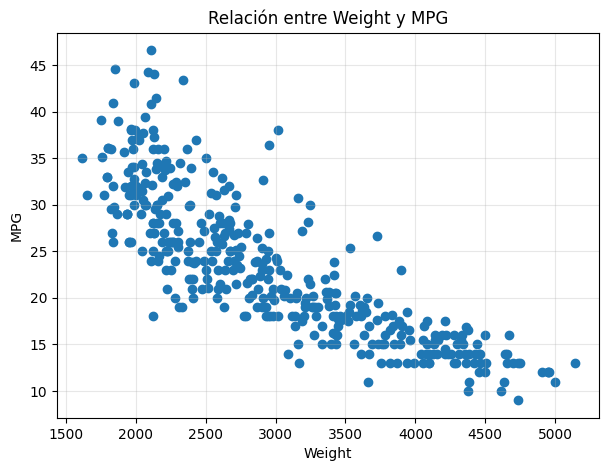

In [10]:
# Importar la librería para generar gráficos
import matplotlib.pyplot as plt

# Graficar la relación entre el peso del vehículo y el rendimiento de combustible
plt.figure(figsize=(7,5))

plt.scatter(df["weight"], df["mpg"])

plt.title("Relación entre Weight y MPG")
plt.xlabel("Weight")
plt.ylabel("MPG")

plt.grid(alpha=0.3)

plt.show()

In [11]:
# Verificar la cantidad de valores faltantes por columna
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

In [12]:
# Verificar si existen registros duplicados
df.duplicated().sum()

np.int64(0)

Verificar calidad de los datos

- Valores faltantes: No se encontraron valores nulos.

- Registros duplicados: No se encontraron registros duplicados.

- Tipos de datos: Los tipos de datos son adecuados para aplicar un modelo de Regresión Lineal.

- Valores atípicos (Outliers): mpg, horsepower, acceleration

- La matriz de correlación mostró que: weight presenta una fuerte correlación negativa con mpg, indicando que los vehículos más pesados tienden a consumir más combustible. horsepower, displacement y cylinders también presentan una correlación negativa importante con mpg. model_year y origin muestran una correlación positiva con la variable objetivo.

- Distribución de la variable objetivo: El histograma de la variable mpg evidencia que la mayor concentración de observaciones se encuentra aproximadamente entre 15 y 30 MPG, con algunos valores extremos superiores a 40 MPG. La distribución es adecuada para realizar el proceso de modelado.

## Preparación de los Datos

Seleccionar los datos

In [13]:
# Eliminar la columna car_name porque no será utilizada en el modelo
df = df.drop(columns=["car_name"])

In [14]:
# Mostrar las columnas que se utilizarán
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin'],
      dtype='str')

Limpiar los datos

In [15]:
# Verificar valores nulos
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

In [18]:
# Reemplazar los valores faltantes de la columna horsepower por la mediana
df["horsepower"] = df["horsepower"].fillna(df["horsepower"].median())

In [20]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

Construir los datos

In [22]:
# Transformar la variable categórica 'origin' en variables binarias
# para que el modelo no interprete un orden entre las categorías.
df = pd.get_dummies(df, columns=["origin"], drop_first=True)

In [23]:
# Mostrar las primeras filas del nuevo conjunto de datos
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_2,origin_3
0,18.0,8,307.0,130.0,3504.0,12.0,70,False,False
1,15.0,8,350.0,165.0,3693.0,11.5,70,False,False
2,18.0,8,318.0,150.0,3436.0,11.0,70,False,False
3,16.0,8,304.0,150.0,3433.0,12.0,70,False,False
4,17.0,8,302.0,140.0,3449.0,10.5,70,False,False


Integrar los datos
- No fue necesario integrar información de otras fuentes, ya que todo el análisis se realizó utilizando el conjunto de datos Auto MPG.

Formatear los datos

In [24]:
# Verificar los tipos de datos del conjunto de datos preparado
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin_2      398 non-null    bool   
 8   origin_3      398 non-null    bool   
dtypes: bool(2), float64(5), int64(2)
memory usage: 22.7 KB


## Modelado

Seleccionar la técnica de modelado

En este proyecto se seleccionó el algoritmo Regresión Lineal, ya que la variable objetivo mpg (Millas por Galón) es una variable numérica continua. La Regresión Lineal, facilitando la predicción del rendimiento de combustible de los vehículos a partir de sus características.

In [25]:
from sklearn.linear_model import LinearRegression

# Crear una instancia del modelo de Regresión Lineal
modelo = LinearRegression()

# Mostrar la configuración del modelo
modelo

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Generar el diseño de prueba

In [26]:
# Separar la variable objetivo (mpg) de las variables predictoras
X = df.drop(columns=["mpg"])
y = df["mpg"]

Para evaluar el desempeño del modelo, el conjunto de datos se dividió en:

- 80 % para entrenamiento.
- 20 % para prueba.

In [ ]:
from sklearn.model_selection import train_test_split

# Dividir los datos en entrenamiento (80 %) y prueba (20 %)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [28]:
# Mostrar las dimensiones de los conjuntos de entrenamiento y prueba
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (318, 8)
X_test : (80, 8)
y_train: (318,)
y_test : (80,)


Construir el modelo

In [29]:
# Entrenar el modelo de Regresión Lineal utilizando los datos de entrenamiento
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[-0.17, 0.02,-0.01,..., 0.83, 2.95, 2.67]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['cylinders','displacement','horsepower',...,'model_year','origin_2', 'origin_3']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-21.86
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


In [30]:
# Realizar predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

Evaluar el Modelo

Las métricas seleccionadas para evaluar el modelo fueron:

- MAE (Error Absoluto Medio)
- MSE (Error Cuadrático Medio)
- RMSE (Raíz del Error Cuadrático Medio)
- R² (Coeficiente de Determinación)

In [34]:
# Importar las métricas de evaluación
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Calcular las métricas
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Mostrar los resultados
print("R²:", round(r2, 4))
print("MAE:", round(mae, 4))
print("MSE:", round(mse, 4))
print("RMSE:", round(rmse, 4))

R²: 0.8449
MAE: 2.2882
MSE: 8.3387
RMSE: 2.8877


## Evaluación

Evaluar los resultados

In [37]:
# Mostrar nuevamente las métricas obtenidas
print("========== Evaluación del Modelo ==========")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")
print(f"Error Absoluto Medio (MAE): {mae:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.4f}")

========== Evaluación del Modelo ==========
Coeficiente de Determinación (R²): 0.8449
Error Absoluto Medio (MAE): 2.2882
Error Cuadrático Medio (MSE): 8.3387
Raíz del Error Cuadrático Medio (RMSE): 2.8877


El modelo de Regresión Lineal obtuvo un coeficiente de determinación (R²) de 0.8449, lo que significa que explica aproximadamente el 84.49 % de la variabilidad del rendimiento de combustible (mpg). Este resultado indica que el modelo presenta un buen ajuste a los datos y una adecuada capacidad predictiva.

El Error Absoluto Medio (MAE) fue de 2.2882, lo que indica que, en promedio, las predicciones difieren del valor real en aproximadamente 2.29 MPG.

El Error Cuadrático Medio (MSE) fue de 8.3387 y la Raíz del Error Cuadrático Medio (RMSE) fue de 2.8877. Esto significa que el error típico de las predicciones es cercano a 2.89 MPG, lo cual puede considerarse aceptable para este conjunto de datos.

En conjunto, las métricas obtenidas muestran que el modelo de Regresión Lineal presenta un buen desempeño para estimar el rendimiento de combustible de los vehículos, ya que explica gran parte de la variabilidad de la variable objetivo y mantiene errores de predicción relativamente bajos.

Modelos aprobados


Justificación de la aprobación

Con base en los resultados obtenidos durante la evaluación, el modelo de Regresión Lineal es aprobado para continuar a la fase de despliegue del proyecto.

Los principales criterios considerados fueron:

- El coeficiente de determinación (R² = 0.8449) indica que el modelo explica aproximadamente el 84.49 % de la variabilidad del consumo de combustible (mpg).
- Los valores obtenidos de MAE, MSE y RMSE muestran que el error de predicción es aceptable para este conjunto de datos.
- Los datos fueron previamente limpiados, preparados y transformados siguiendo la metodología CRISP-DM, garantizando una adecuada calidad de la información.
- El modelo cumple con el objetivo de minería de datos planteado: predecir el rendimiento de combustible (mpg) a partir de las características técnicas de los vehículos.

Determine Next Steps

Próximos pasos

- Aprobar el modelo como resultado final del proceso de modelado.
- Concluir la fase de Evaluación de la metodología CRISP-DM.
- Documentar los resultados obtenidos, las métricas de desempeño y las conclusiones del proyecto.

## Despliegue

Plan de despliegue

El modelo será implementado dentro de un entorno donde pueda recibir nuevos registros de vehículos y generar predicciones automáticamente.
El proceso de predicción seguirá el siguiente flujo:
1. Ingreso de características del vehículo
2. Validación y preparación de datos
3. Aplicación del modelo entrenado
4. Generación de predicción de consumo (mpg)
5. Presentación del resultado

Plan de Monitoreo y Mantenimiento

Actividades de monitoreo

- Verificar periódicamente la precisión de las predicciones del modelo.
- Comparar los valores predichos con los valores reales cuando estos estén disponibles.
- Identificar posibles cambios en los datos que puedan afectar el rendimiento del modelo.

Actividades de mantenimiento

- Actualizar el conjunto de datos cuando se disponga de nueva información.
- Reentrenar el modelo si las métricas de evaluación muestran una disminución significativa en su desempeño.
- Revisar la calidad de los datos antes de realizar nuevas predicciones para evitar errores ocasionados por datos incompletos o inconsistentes.

Producir Informe Final


Objetivo del proyecto

Desarrollar un modelo de Regresión Lineal capaz de predecir el rendimiento de combustible (mpg) de los vehículos utilizando sus características técnicas.

Metodología aplicada

El proyecto fue desarrollado siguiendo la metodología CRISP-DM, cumpliendo las siguientes fases:

1. Comprensión del negocio.
2. Comprensión de los datos.
3. Preparación de los datos.
4. Modelado.
5. Evaluación.
6. Despliegue.

Desarrollo realizado

- Se cargó y exploró el conjunto de datos de vehículos.
- Se realizó la limpieza y preparación de los datos.
- Se seleccionaron las variables relevantes para el modelo.
- Se dividieron los datos en conjuntos de entrenamiento y prueba.
- Se entrenó un modelo de **Regresión Lineal**.
- Se evaluó el modelo utilizando las métricas **R², MAE, MSE y RMSE**.

Resultados obtenidos

El modelo obtuvo un coeficiente de determinación **R² = 0.8449**, lo que indica que explica aproximadamente el **84.49 %** de la variabilidad del rendimiento de combustible. Las métricas de error mostraron un desempeño adecuado para el problema planteado.

Conclusiones

- El modelo de Regresión Lineal resultó adecuado para la predicción del rendimiento de combustible.
- La calidad y preparación de los datos influyeron significativamente en el desempeño del modelo.
- La metodología CRISP-DM permitió desarrollar el proyecto de manera estructurada y ordenada.
- El modelo quedó preparado para ser utilizado en futuras predicciones y como base para posibles mejoras o implementaciones posteriores.

Revisión del Proyecto

Verificación de objetivos

- Se comprendió el problema de negocio y se definió el objetivo de predecir el rendimiento de combustible (mpg) de los vehículos.
- Se exploró y analizó el conjunto de datos, identificando sus principales características.
- Se prepararon los datos mediante procesos de limpieza y selección de variables.
- Se desarrolló un modelo de Regresión Lineal para realizar las predicciones.
- El modelo fue evaluado utilizando las métricas R², MAE, MSE y RMSE, obteniendo resultados satisfactorios.
- Se elaboró un plan de despliegue y un plan de monitoreo para el uso futuro del modelo.

Conclusión

El proyecto cumplió con el objetivo de desarrollar un modelo de Regresión Lineal capaz de predecir el rendimiento de combustible de los vehículos. Asimismo, se completaron satisfactoriamente todas las fases de la metodología CRISP-DM, desde la comprensión del negocio hasta el despliegue del modelo, obteniendo un resultado útil y bien documentado.